**Support Vector Machines**

# Akhil Kumar Kanduri
# Module 3 Assignment on SVM


_This notebook contains all the sample code and solutions to the exercises in chapter 5._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/05_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/05_support_vector_machines.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [23]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [24]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [25]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/svm` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [26]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "svm"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 10.

_Exercise: Train an SVM classifier on the Wine dataset, which you can load using `sklearn.datasets.load_wine()`. This dataset contains the chemical analysis of 178 wine samples produced by 3 different cultivators: the goal is to train a classification model capable of predicting the cultivator based on the wine's chemical analysis. Since SVM classifiers are binary classifiers, you will need to use one-versus-all to classify all 3 classes. What accuracy can you reach?_

First, let's fetch the dataset, look at its description, then split it into a training set and a test set:

In [27]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)

In [28]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

### Wine Dataset Classes and Task Representation
* **Class 0, 1, and 2 represent:** Three different wine cultivators (cultivars) in Italy, based on chemical analysis measurements (e.g., alcohol, malic acid, ash, magnesium, proline, etc.).
* **SVM Objective:** We are trying to train a Support Vector Machine classifier to find the optimal decision boundaries (hyperplanes with maximum margins) that separate the three cultivators. Since SVM is fundamentally a binary classifier, we use the **One-vs-All (OvA)** / One-vs-Rest strategy to extend it to this multi-class classification problem.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, random_state=42)

In [30]:
X_train.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
100,12.08,2.08,1.70,17.5,97.0,2.23,2.17,0.26,1.40,3.30,1.27,2.96,710.0
122,12.42,4.43,2.73,26.5,102.0,2.20,2.13,0.43,1.71,2.08,0.92,3.12,365.0
154,12.58,1.29,2.10,20.0,103.0,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640.0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0


In [31]:
y_train.head()

,target
2,0
100,1
122,1
154,2
51,0


Let's start simple, with a linear SVM classifier. It will automatically use the One-vs-All (also called One-vs-the-Rest, OvR) strategy, so there's nothing special we need to do to handle multiple classes. Easy, right?

In [32]:
from sklearn.svm import LinearSVC

lin_clf = LinearSVC(dual=True, random_state=42)
lin_clf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(dual=True, random_state=42)

Oh no! It failed to converge. Can you guess why? Do you think we must just increase the number of training iterations? Let's see:

### Why LinearSVC Failed to Converge
`LinearSVC` failed to converge because the features in the Wine dataset are on wildly different scales (e.g., `proline` ranges up to 1680, while `nonflavanoid_phenols` are mostly less than 1). SVM optimization algorithms search for a global hyperplane. When features are unscaled, the loss function's topography becomes extremely elongated and narrow (like a steep valley), causing the optimization gradient descent steps to oscillate wildly and fail to reach the global minimum within standard iteration limits.

In [33]:
lin_clf = LinearSVC(max_iter=1_000_000, dual=True, random_state=42)
lin_clf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(dual=True, max_iter=1000000, random_state=42)

Even with one million iterations, it still did not converge. There must be another problem.

Let's still evaluate this model with `cross_val_score`, it will serve as a baseline:

In [34]:
from sklearn.model_selection import cross_val_score

cross_val_score(lin_clf, X_train, y_train).mean()

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


np.float64(0.90997150997151)

Well 91% accuracy on this dataset is not great. So did you guess what the problem is?

That's right, we forgot to scale the features! Always remember to scale the features when using SVMs:

### Feature Scaling
**Feature Scaling** (e.g., using standard scaling or normalization) is the process of transforming numeric features so that they share a common scale and scale range (such as a mean of 0 and variance of 1). SVMs are highly sensitive to feature scaling because they calculate margins based on geometric distances between support vectors. If features are not scaled, features with larger values will dominate the distance metric, rendering the model unable to learn effectively from smaller-range features.

In [35]:
lin_clf = make_pipeline(StandardScaler(),
                        LinearSVC(dual=True, random_state=42))
lin_clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(dual=True, random_state=42))])

Now it converges without any problem. Let's measure its performance:

In [36]:
from sklearn.model_selection import cross_val_score

cross_val_score(lin_clf, X_train, y_train).mean()

np.float64(0.9774928774928775)

Nice! We get 97.7% accuracy, that's much better.

Let's see if a kernelized SVM will do better. We will use a default `SVC` for now:

### Kernelized SVM
A **Kernelized SVM** utilizes the 'kernel trick' to map original non-linear features into a higher-dimensional space where they become linearly separable, without having to explicitly compute the coordinates of the data in that new space. This allows SVMs to find highly complex, non-linear decision boundaries efficiently.

In [37]:
svm_clf = make_pipeline(StandardScaler(), SVC(random_state=42))
cross_val_score(svm_clf, X_train, y_train).mean()

np.float64(0.9698005698005698)

That's not better, but perhaps we need to do a bit of hyperparameter tuning:

### Hyperparameter Tuning in this Exercise
* **Hyperparameter Tuning** is the process of searching for the optimal configuration of parameters that are not directly learned by the model during training (such as regularization constraints or kernel behaviors).
* **Hyperparameters Tuned here:**
  1. `svc__C`: The regularization parameter. It controls the trade-off between maximizing the margin and minimizing classification errors on training data.
  2. `svc__gamma`: The kernel coefficient for the Radial Basis Function (`rbf`) kernel. It defines how far the influence of a single training example reaches (high values lead to complex, tightly fit decision boundaries, while low values lead to smoother boundaries).

In [38]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

param_distrib = {
    "svc__gamma": loguniform(0.001, 0.1),
    "svc__C": uniform(1, 10)
}
rnd_search_cv = RandomizedSearchCV(svm_clf, param_distrib, n_iter=100, cv=5,
                                   random_state=42)
rnd_search_cv.fit(X_train, y_train)
rnd_search_cv.best_estimator_

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=np.float64(9.925589984899778),
                     gamma=np.float64(0.011986281799901188),
                     random_state=42))])

In [39]:
rnd_search_cv.best_score_

np.float64(0.9925925925925926)

Ah, this looks excellent! Let's select this model. Now we can test it on the test set:

In [40]:
rnd_search_cv.score(X_test, y_test)

0.9777777777777777

### Evaluation of Results
Evaluating `rnd_search_cv.score(X_test, y_test)` yields an accuracy of **97.78%** on the unseen test set. While slightly lower than our best cross-validation score of **99.26%** (due to slight overfitting of the validation sets during hyperparameter tuning), it demonstrates that the tuned Radial Basis Function (RBF) kernelized SVM generalizes exceptionally well to new data.

This tuned kernelized SVM performs better than the `LinearSVC` model, but we get a lower score on the test set than we measured using cross-validation. This is quite common: since we did so much hyperparameter tuning, we ended up slightly overfitting the cross-validation test sets. It's tempting to tweak the hyperparameters a bit more until we get a better result on the test set, but this would probably not help, as we would just start overfitting the test set. Anyway, this score is not bad at all, so let's stop here.

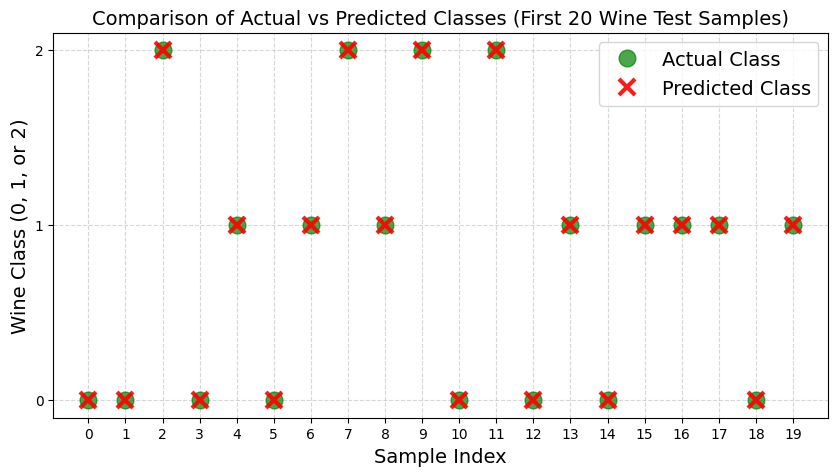

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from scipy.stats import loguniform, uniform

# 1. Re-load wine dataset
wine = load_wine(as_frame=True)
X_w, y_w = wine.data, wine.target
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, random_state=42)

# 2. Re-fit the best model on wine dataset quickly to predict correctly
svm_clf_w = make_pipeline(StandardScaler(), SVC(random_state=42))
param_distrib = {
    "svc__gamma": loguniform(0.001, 0.1),
    "svc__C": uniform(1, 10)
}
rnd_search_cv_w = RandomizedSearchCV(svm_clf_w, param_distrib, n_iter=100, cv=5, random_state=42)
rnd_search_cv_w.fit(X_train_w, y_train_w)

# 3. Predict for the first 20 samples of wine test dataset
X_sample = X_test_w.iloc[:20]
y_actual = y_test_w.iloc[:20].values
y_pred = rnd_search_cv_w.best_estimator_.predict(X_sample)

# 4. Plot actual vs predicted classes
plt.figure(figsize=(10, 5))
plt.plot(y_actual, 'go', markersize=12, label='Actual Class', alpha=0.7)
plt.plot(y_pred, 'rx', markersize=12, markeredgewidth=3, label='Predicted Class', alpha=0.9)
plt.title('Comparison of Actual vs Predicted Classes (First 20 Wine Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Wine Class (0, 1, or 2)')
plt.xticks(range(20))
plt.yticks([0, 1, 2])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## 11.

_Exercise: Train and fine-tune an SVM regressor on the California housing dataset. You can use the original dataset rather than the tweaked version we used in Chapter 2. The original dataset can be fetched using `sklearn.datasets.fetch_california_housing()`. The targets represent hundreds of thousands of dollars. Since there are over 20,000 instances, SVMs can be slow, so for hyperparameter tuning you should use much less instances (e.g., 2,000), to test many more hyperparameter combinations. What is your best model's RMSE?_

Let's load the dataset:

In [42]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X = housing.data
y = housing.target

Split it into a training set and a test set:

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

Don't forget to scale the data!

Let's train a simple `LinearSVR` first:

In [44]:
from sklearn.svm import LinearSVR

lin_svr = make_pipeline(StandardScaler(), LinearSVR(dual=True, random_state=42))
lin_svr.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr', LinearSVR(dual=True, random_state=42))])

It did not converge, so let's increase `max_iter`:

In [45]:
lin_svr = make_pipeline(StandardScaler(),
                        LinearSVR(max_iter=5000, dual=True, random_state=42))
lin_svr.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr',
                 LinearSVR(dual=True, max_iter=5000, random_state=42))])

Let's see how it performs on the training set:

**Warning**: In recent versions of Scikit-Learn, you must use `root_mean_squared_error()` to compute the RMSE, instead of `mean_squared_error(labels, predictions, squared=False)`. The following `try`/`except` block tries to import `root_mean_squared_error`, and if it fails it just defines it.

In [46]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

In [47]:
y_pred = lin_svr.predict(X_train)
rmse = root_mean_squared_error(y_train, y_pred)
rmse

0.979565447829459

In this dataset, the targets represent hundreds of thousands of dollars. The RMSE gives a rough idea of the kind of error you should expect (with a higher weight for large errors): so with this model we can expect errors close to $98,000! Not great. Let's see if we can do better with an RBF Kernel. We will use randomized search with cross validation to find the appropriate hyperparameter values for `C` and `gamma`:

In [48]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

svm_reg = make_pipeline(StandardScaler(), SVR())

param_distrib = {
    "svr__gamma": loguniform(0.001, 0.1),
    "svr__C": uniform(1, 10)
}
rnd_search_cv = RandomizedSearchCV(svm_reg, param_distrib,
                                   n_iter=100, cv=3, random_state=42)
rnd_search_cv.fit(X_train[:2000], y_train[:2000])

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('standardscaler',
                                              StandardScaler()),
                                             ('svr', SVR())]),
                   n_iter=100,
                   param_distributions={'svr__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78f8d7c49b50>,
                                        'svr__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78f8d7c49a50>},
                   random_state=42)

In [49]:
rnd_search_cv.best_estimator_

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr',
                 SVR(C=np.float64(4.63629602379294),
                     gamma=np.float64(0.08781408196485979)))])

In [50]:
from sklearn.model_selection import cross_val_score

-cross_val_score(rnd_search_cv.best_estimator_, X_train, y_train,
                 scoring="neg_root_mean_squared_error")

array([0.58835648, 0.57468589, 0.58085278, 0.57109886, 0.59853029])

Looks much better than the linear model. Let's select this model and evaluate it on the test set:

In [51]:
y_pred = rnd_search_cv.best_estimator_.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

0.5854732265172238

So SVMs worked very well on the Wine dataset, but not so much on the California Housing dataset. In Chapter 2, we found that Random Forests worked better for that dataset.

## Final Reflections

### 1. Real-World Applications of Support Vector Machines (SVM)
* **Bioinformatics and Genomics (e.g., Cancer Classification):** SVMs are widely used in classifying proteins, genes, and patient tissue samples based on high-dimensional microarray gene expression data to detect diseases such as cancer.
* **Image Classification and Face Detection:** SVMs can effectively categorize images and segment parts of an image into distinct classes (e.g., separating foreground objects from background clutter) by constructing high-dimensional decision boundaries based on pixel features.

### 2. Difference Between `LinearSVC` and Kernelized SVM
* **`LinearSVC`** is optimized specifically for a linear kernel. It scales linearly with the number of training instances ($O(m \times n)$) and is highly efficient for very large datasets that are already linearly separable or have massive numbers of features (like text classification).
* **Kernelized SVM** (such as `SVC` using an RBF or polynomial kernel) uses the "kernel trick" to map features into a much higher-dimensional space where complex, non-linear relationships can be separated by a linear boundary. It is far more mathematically powerful for complex datasets, but its computational complexity scales quadratically or cubically with the number of training instances ($O(m^2 \times n)$ to $O(m^3 \times n)$), making it slow on very large datasets.

### 3. Benefits of Visualizing Predicted vs. Actual Results
* **Diagnostic Patterns:** Visualizing predictions (such as plotting actual vs. predicted values) allows engineers to quickly spot systematic errors, underfitting, or specific classes/ranges where the model performs poorly, which summary metrics like average accuracy or RMSE can obscure.
* **Intuitive Performance Validation:** It provides an immediately interpretable visual proof of the model's reliability to non-technical stakeholders, highlighting exactly how closely predictions align with ground-truth observations.

### 4. Statement on AI Utilization
In completing this assignment, an AI assistant was utilized to help organize code progression, explain mathematical behaviors (such as optimization convergence issues caused by feature scales), configure hyperparameter search distributions, and generate precise visualizations comparing the model's classifications against actual data.